In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os
from transformer_lens import HookedTransformer, HookedTransformerConfig
import yaml

In [3]:
torch.manual_seed(89)
np.random.seed(42)

In [4]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

f'{DEVICE}'

'cuda'

In [5]:
# read configs
with open ('../configs/configs.yaml', 'r') as _cfg:
    configs = yaml.safe_load(_cfg)

In [6]:
from pprint import pprint

pprint(configs)

{'data': {'operation': 'addition', 'p': 113},
 'logging': {'checkpoint_every': 1000,
             'log_every': 100,
             'save_dir': 'checkpoints'},
 'model': {'act_fn': 'relu',
           'd_head': 64,
           'd_mlp': 512,
           'd_model': 128,
           'd_vocab': 114,
           'n_ctx': 3,
           'n_heads': 2,
           'n_layers': 1,
           'normalization_type': None},
 'optimizer': {'betas': [0.9, 0.98],
               'lr': 0.001,
               'name': 'AdamW',
               'weight_decay': 1.0},
 'training': {'batch_size': None, 'device': 'cuda', 'num_epochs': 40000}}


In [7]:
config = configs['model']

In [8]:
# load data from torch shards

data = torch.load('../data/dataset.pt')

In [9]:
x, y = data['x'], data['y']

x, y

(tensor([[  0,   0, 113],
         [  0,   1, 113],
         [  0,   2, 113],
         ...,
         [112, 110, 113],
         [112, 111, 113],
         [112, 112, 113]]),
 tensor([  0,   1,   2,  ..., 109, 110, 111]))

In [10]:
print(
f'''len x: {len(x)},
len y: {len(y)}'''
)

len x: 12769,
len y: 12769


In [11]:
from torch.utils.data import TensorDataset, random_split

dataset = TensorDataset(x, y)

data_train, data_val = random_split(dataset, [0.5, 0.5])

In [12]:
train_idx = data_train.indices
val_idx = data_val.indices

train_x, train_y = x[train_idx].to(DEVICE), y[train_idx].to(DEVICE)
val_x, val_y = x[val_idx].to(DEVICE), y[val_idx].to(DEVICE)

In [13]:
# initializin the transformer configs using transformer lesn

config

{'n_layers': 1,
 'd_model': 128,
 'd_mlp': 512,
 'd_head': 64,
 'n_heads': 2,
 'n_ctx': 3,
 'd_vocab': 114,
 'act_fn': 'relu',
 'normalization_type': None}

In [14]:
cfg = HookedTransformerConfig(**config)

cfg

HookedTransformerConfig:
{'NTK_by_parts_factor': 8.0,
 'NTK_by_parts_high_freq_factor': 4.0,
 'NTK_by_parts_low_freq_factor': 1.0,
 'NTK_original_ctx_len': 8192,
 'act_fn': 'relu',
 'attention_dir': 'causal',
 'attn_only': False,
 'attn_scale': np.float64(8.0),
 'attn_scores_soft_cap': -1.0,
 'attn_types': None,
 'checkpoint_index': None,
 'checkpoint_label_type': None,
 'checkpoint_value': None,
 'd_head': 64,
 'd_mlp': 512,
 'd_model': 128,
 'd_vocab': 114,
 'd_vocab_out': 114,
 'decoder_start_token_id': None,
 'default_prepend_bos': True,
 'device': 'cuda',
 'dtype': torch.float32,
 'eps': 1e-05,
 'experts_per_token': None,
 'final_rms': False,
 'from_checkpoint': False,
 'gated_mlp': False,
 'init_mode': 'gpt2',
 'init_weights': True,
 'initializer_range': np.float64(0.07071067811865475),
 'layer_norm_folding': False,
 'load_in_4bit': False,
 'model_name': 'custom',
 'n_ctx': 3,
 'n_devices': 1,
 'n_heads': 2,
 'n_key_value_heads': None,
 'n_layers': 1,
 'n_params': 196608,
 'norm_

In [15]:
model = HookedTransformer(cfg).to(DEVICE)

Moving model to device:  cuda


In [16]:
sum(p.numel() for p in model.parameters())

227442

In [19]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0) # yes i wont be using configs.yaml cfgs from here 😝

epochs = 5000

In [ ]:
train_accs, val_accs = [], []
grok_epoch = None

@torch.no_grad()
def evaluate(x, y):
    logits = model(x)[:, 2, :]  # position 2 is "=" token, where the answer is predicted
    return (logits.argmax(-1) == y).float().mean().item()

for epoch in range(1, epochs + 1):
    model.train()
    logits = model(train_x)[:, 2, :]
    loss = F.cross_entropy(logits, train_y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model.eval()
        t_acc = evaluate(train_x, train_y)
        v_acc = evaluate(val_x, val_y)
        train_accs.append(t_acc)
        val_accs.append(v_acc)

        if grok_epoch is None and v_acc > 0.95:
            grok_epoch = epoch
            print(f"GROKKKKED !!! at epoch {epoch}")

        if epoch % 500 == 0:
            print(f"epoch {epoch} | loss {loss.item():.4f} | train {t_acc:.1%} | val {v_acc:.1%}")

epoch 500 | loss 0.0058 | train 100.0% | val 86.7%
GROKKED at epoch 610
epoch 1000 | loss 0.0021 | train 100.0% | val 100.0%
epoch 1500 | loss 0.0011 | train 100.0% | val 100.0%
epoch 2000 | loss 0.0007 | train 100.0% | val 100.0%
epoch 2500 | loss 0.0005 | train 100.0% | val 100.0%
epoch 3000 | loss 0.0004 | train 100.0% | val 100.0%
epoch 3500 | loss 0.0003 | train 100.0% | val 100.0%
epoch 4000 | loss 0.0002 | train 100.0% | val 100.0%
epoch 4500 | loss 0.0002 | train 100.0% | val 100.0%
epoch 5000 | loss 0.0001 | train 100.0% | val 100.0%


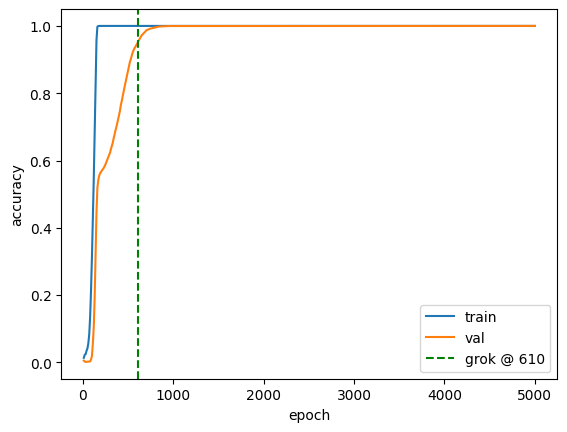

In [ ]:
epochs_logged = list(range(10, epochs + 1, 10))

plt.plot(epochs_logged, train_accs, label="train")
plt.plot(epochs_logged, val_accs, label="val")
if grok_epoch:
    plt.axvline(grok_epoch, linestyle="--", color="green", label=f"grok @ {grok_epoch}")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [ ]:
train_set = set(map(tuple, train_x.cpu().tolist()))
val_set = set(map(tuple, val_x.cpu().tolist()))
print(len(train_set & val_set)) # data leakage check

0


In [ ]:
print(optimizer.param_groups[0]['weight_decay'])

1.0


In [25]:
print(train_x[:10])
print(train_y[:10])

tensor([[ 73,  78, 113],
        [ 64,  95, 113],
        [ 25,  81, 113],
        [ 15,  99, 113],
        [ 74,  59, 113],
        [  2, 110, 113],
        [ 91,  35, 113],
        [  3,  82, 113],
        [ 76,  29, 113],
        [ 39,  12, 113]], device='cuda:0')
tensor([ 38,  46, 106,   1,  20, 112,  13,  85, 105,  51], device='cuda:0')
